# Notebook 8 – Decision Trees


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv", encoding="latin1")
df = df.dropna(subset=["Description"]).copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").astype(int)
df["AbsQuantity"] = df["Quantity"].abs()
df["Month"] = df["InvoiceDate"].dt.month
df["IsInternational"] = (df["Country"] != "United Kingdom").astype(int)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,AbsQuantity,Month,IsInternational
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,6,12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0,8,12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0


## Decision Tree

**What it is:** a classification (or regression) model shaped like a
flowchart. It asks a series of yes/no questions about the features, one at
a time, each question narrowing down the data, until it reaches an answer.
Unlike Logistic Regression or Naive Bayes, a Decision Tree makes no
assumption about the shape of the data (no sigmoid, no independence, no
bell curve); it just repeatedly splits the data into smaller, more
"pure" (single-class) groups.

## Root Node, Internal Node, Leaf Node

A Decision Tree is made of three kinds of nodes:

* **Root Node** — the very top of the tree, where the first (and most
  informative) question is asked, using the *entire* training set.
* **Internal Node** — any node below the root that still asks another
  question, splitting its (already-narrowed-down) subset of the data
  further.
* **Leaf Node** — a node at the bottom of a branch that asks no more
  questions; it just outputs a prediction (a class label, or in
  scikit-learn's case, the class probabilities of whatever training rows
  ended up there).

Every path from the root to a leaf is one chain of yes/no questions that
ends in a prediction.

## Splitting

**What it is:** the process of picking, at each node, *which feature* and
*which threshold* divides the current data into the purest possible two
groups. For a numeric feature like `UnitPrice`, a split looks like
`UnitPrice <= 2.95`; every row that satisfies it goes one way, everything
else goes the other. The tree tries many candidate features and
thresholds and keeps whichever split produces the biggest improvement in
purity.

## Entropy and Gini Impurity

Both are ways of measuring how "mixed" a node's classes are, so the tree
can judge which candidate split produces purer children.

* **Entropy** (from information theory): `-sum(p_i * log2(p_i))` over each
  class `i`. It's 0 for a perfectly pure node (only one class present) and
  highest when classes are evenly mixed.
* **Gini Impurity**: `1 - sum(p_i^2)`. It measures the probability of
  misclassifying a randomly picked row if it were labeled according to the
  class distribution at that node. Also 0 for a pure node.

They usually agree on which split is best; Gini is scikit-learn's default
because it's slightly cheaper to compute (no logarithms).

In [3]:
def entropy(p):
    p = np.array(p)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def gini(p):
    p = np.array(p)
    return 1 - np.sum(p ** 2)

# A pure node (all one class) vs. an evenly-mixed node
pure_node = [1.0, 0.0]
mixed_node = [0.5, 0.5]
slightly_mixed_node = [0.9, 0.1]

for name, dist in [("Pure", pure_node), ("Evenly mixed", mixed_node), ("Slightly mixed", slightly_mixed_node)]:
    print(f"{name:16s} -> Entropy: {entropy(dist):.4f}   Gini: {gini(dist):.4f}")

Pure             -> Entropy: -0.0000   Gini: 0.0000
Evenly mixed     -> Entropy: 1.0000   Gini: 0.5000
Slightly mixed   -> Entropy: 0.4690   Gini: 0.1800


## Information Gain

**What it is:** the reduction in impurity (entropy or Gini) achieved by a
split — the impurity of the parent node, minus the weighted average
impurity of the resulting child nodes. At every node, the tree evaluates
every candidate split's information gain and picks the one that gains the
most. A gain of 0 means the split didn't help at all.

In [4]:
# Manually verifying information gain for the IsCancelled target, split on IsInternational
parent_dist = df["IsCancelled"].value_counts(normalize=True).sort_index().values
parent_entropy = entropy(parent_dist)

domestic = df[df["IsInternational"] == 0]
international = df[df["IsInternational"] == 1]

domestic_entropy = entropy(domestic["IsCancelled"].value_counts(normalize=True).sort_index().values)
international_entropy = entropy(international["IsCancelled"].value_counts(normalize=True).sort_index().values)

weighted_child_entropy = (
    (len(domestic) / len(df)) * domestic_entropy +
    (len(international) / len(df)) * international_entropy
)

information_gain = parent_entropy - weighted_child_entropy

print("Parent entropy (IsCancelled overall):", round(parent_entropy, 4))
print("Weighted child entropy (split on IsInternational):", round(weighted_child_entropy, 4))
print("Information Gain from this split:", round(information_gain, 4))

Parent entropy (IsCancelled overall): 0.1253
Weighted child entropy (split on IsInternational): 0.1247
Information Gain from this split: 0.0006


## Training a Decision Tree

**Our example:** the same task as Notebooks 5 and 7 — predicting
`IsCancelled` from `AbsQuantity`, `UnitPrice`, `Month`, and
`IsInternational` — so results are directly comparable across models.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

feature_cols = ["AbsQuantity", "UnitPrice", "Month", "IsInternational"]
X = df[feature_cols]
y = df["IsCancelled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
tree_predictions = tree_model.predict(X_test)

print(classification_report(y_test, tree_predictions, zero_division=0))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    106233
           1       0.32      0.01      0.01      1858

    accuracy                           0.98    108091
   macro avg       0.65      0.50      0.50    108091
weighted avg       0.97      0.98      0.97    108091



## Visualizing the Trained Decision Tree

`max_depth=4` was chosen deliberately (see "Tree Depth" below) to keep the
diagram small enough to actually read. Each box shows: the splitting
question, the Gini impurity at that node, how many training samples
reached it, the class proportions (`[not cancelled, cancelled]`), and the
majority class.

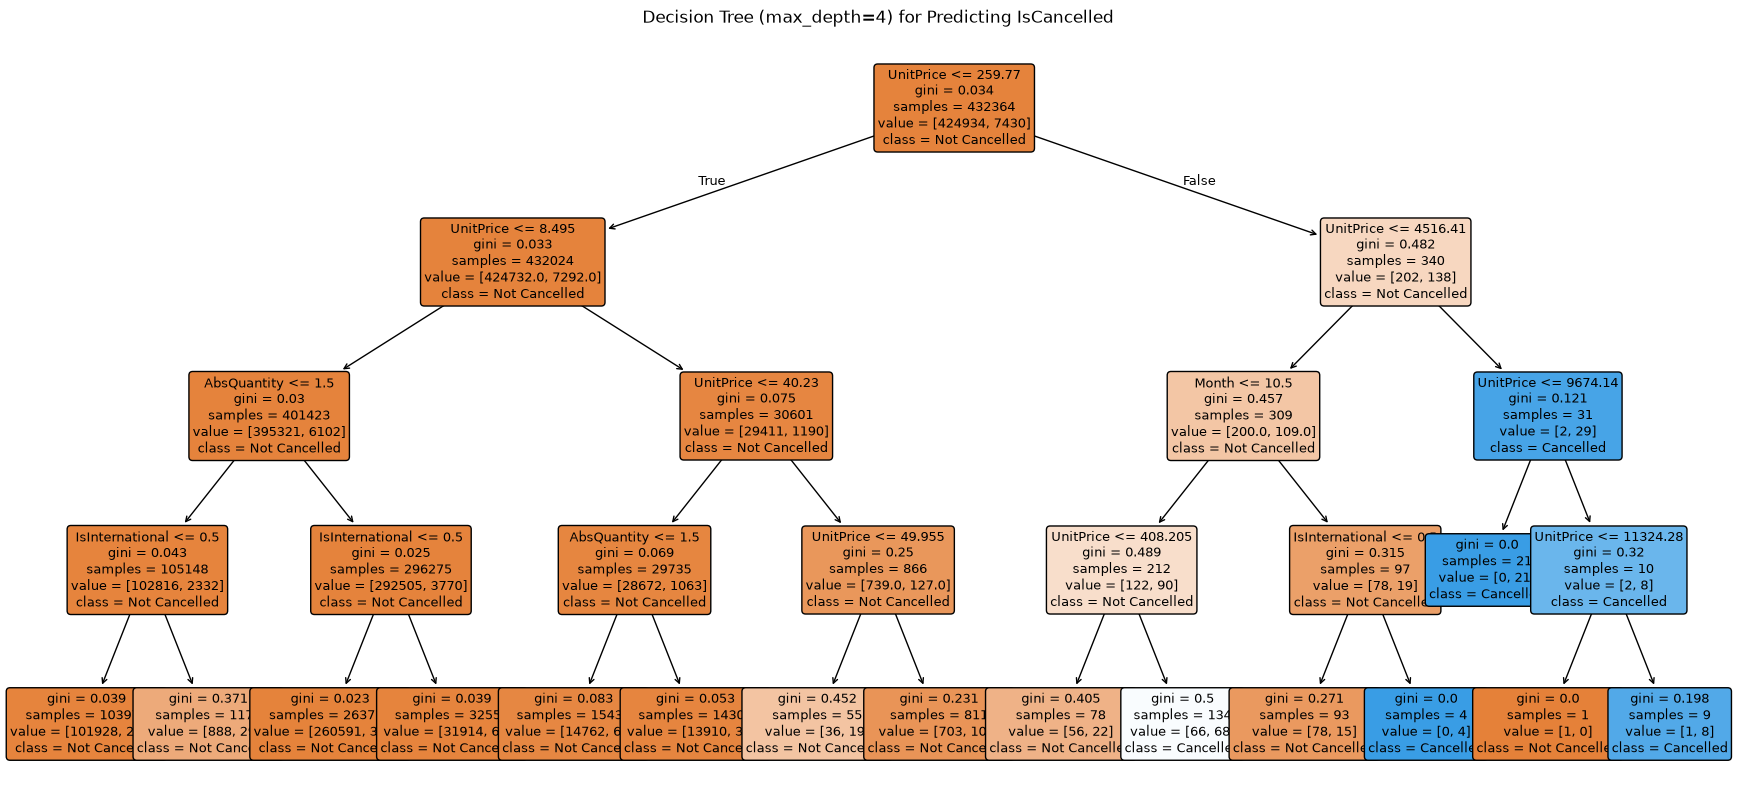

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=feature_cols,
    class_names=["Not Cancelled", "Cancelled"],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Decision Tree (max_depth=4) for Predicting IsCancelled")
plt.show()

## How the Tree Arrives at a Prediction

A trained tree makes a prediction by starting at the root and following
one path down to a leaf, answering each node's yes/no question with the
new row's own feature values. Below, one actual test-set row is traced
through the tree step by step, printing the exact question asked at each
node it visits, and the answer that sent it left or right, ending at the
leaf that produced its prediction.

In [7]:
def trace_prediction(model, row, feature_names):
    tree = model.tree_
    node = 0
    print("Row's feature values:")
    for name in feature_names:
        print(f"  {name} = {row[name]}")
    print()
    while tree.feature[node] != -2:  # -2 marks a leaf node
        feat_index = tree.feature[node]
        feat_name = feature_names[feat_index]
        threshold = tree.threshold[node]
        value = row[feat_name]
        goes_left = value <= threshold
        direction = "LEFT (True)" if goes_left else "RIGHT (False)"
        print(f"Node {node}: is {feat_name} <= {threshold:.3f}?  "
              f"({feat_name}={value} -> {value <= threshold}) -> go {direction}")
        node = tree.children_left[node] if goes_left else tree.children_right[node]
    class_proportions = tree.value[node][0]
    n_samples = tree.n_node_samples[node]
    predicted_class = np.argmax(class_proportions)
    print(f"\nReached leaf node {node} ({n_samples} training samples landed here). "
          f"Class proportions [not cancelled, cancelled]: {np.round(class_proportions, 4)} "
          f"-> predicted class = {predicted_class} "
          f"({'Cancelled' if predicted_class == 1 else 'Not Cancelled'})")

sample_row = X_test.iloc[0]
trace_prediction(tree_model, sample_row, feature_cols)
print("\nModel's own .predict() for this row:", tree_model.predict(X_test.iloc[[0]])[0])

Row's feature values:
  AbsQuantity = 20.0
  UnitPrice = 2.08
  Month = 11.0
  IsInternational = 0.0

Node 0: is UnitPrice <= 259.770?  (UnitPrice=2.08 -> True) -> go LEFT (True)
Node 1: is UnitPrice <= 8.495?  (UnitPrice=2.08 -> True) -> go LEFT (True)
Node 2: is AbsQuantity <= 1.500?  (AbsQuantity=20.0 -> False) -> go RIGHT (False)
Node 6: is IsInternational <= 0.500?  (IsInternational=0.0 -> True) -> go LEFT (True)

Reached leaf node 7 (263720 training samples landed here). Class proportions [not cancelled, cancelled]: [0.9881 0.0119] -> predicted class = 0 (Not Cancelled)

Model's own .predict() for this row: 0


## Tree Depth

**What it is:** the number of splits between the root node and the
furthest leaf. A shallow tree (small `max_depth`) can only ask a few
questions before committing to a prediction, so it captures only the
broadest patterns. A deep tree can keep splitting the data into smaller
and smaller, more specific groups, potentially isolating individual
training rows into their own leaves.

Depth is one of the main knobs for controlling how complex — and how
overfit — a tree is allowed to become.

## Overfitting

**What it is:** when a model fits the training data *too* well, learning
the noise and quirks of those specific rows rather than the general
pattern, and consequently performs worse on new, unseen data. Decision
Trees are especially prone to this: left unrestricted, a tree can keep
splitting until every leaf contains just one or a handful of training
rows, essentially "memorizing" the training set.

Below, an unrestricted tree (no `max_depth` limit) is compared against the
shallow, depth-4 tree from before, on both the training set and the test
set.

In [8]:
deep_tree_model = DecisionTreeClassifier(random_state=42)  # no max_depth limit
deep_tree_model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

print(f"{'Model':30s} {'Train Accuracy':>15s} {'Test Accuracy':>15s} {'Tree Depth':>12s}")
for name, model in [("Shallow tree (max_depth=4)", tree_model), ("Unrestricted tree", deep_tree_model)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:30s} {train_acc:15.4f} {test_acc:15.4f} {model.get_depth():12d}")

Model                           Train Accuracy   Test Accuracy   Tree Depth
Shallow tree (max_depth=4)              0.9829          0.9827            4
Unrestricted tree                       0.9852          0.9822           33


Notice the unrestricted tree's much higher training accuracy and much
deeper depth, meanwhile its test accuracy barely improves (or gets worse)
compared to the shallow tree. That gap between training and test
performance is the signature of overfitting: the deep tree learned
patterns specific to the training rows that don't generalize.

## Pruning

**What it is:** deliberately simplifying a tree to fight overfitting,
either by stopping it from growing too complex in the first place
(**pre-pruning**, e.g. setting `max_depth`, `min_samples_leaf`, or
`min_samples_split` before training) or by growing a full tree and then
trimming branches back afterward (**post-pruning**, e.g. scikit-learn's
`ccp_alpha` cost-complexity pruning).

Below, cost-complexity pruning is applied to the previously unrestricted
tree, comparing a few `ccp_alpha` values to see how pruning trades a
little training accuracy for a smaller tree and (hopefully) better
generalization.

In [9]:
for alpha in [0.0, 0.00005, 0.0001, 0.0003, 0.001]:
    pruned_model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    pruned_model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, pruned_model.predict(X_train))
    test_acc = accuracy_score(y_test, pruned_model.predict(X_test))
    print(f"ccp_alpha={alpha:<8} train_acc={train_acc:.4f}  test_acc={test_acc:.4f}  depth={pruned_model.get_depth():3d}  leaves={pruned_model.get_n_leaves()}")

ccp_alpha=0.0      train_acc=0.9852  test_acc=0.9822  depth= 33  leaves=6806
ccp_alpha=5e-05    train_acc=0.9828  test_acc=0.9828  depth=  4  leaves=5
ccp_alpha=0.0001   train_acc=0.9828  test_acc=0.9828  depth=  4  leaves=5
ccp_alpha=0.0003   train_acc=0.9828  test_acc=0.9828  depth=  0  leaves=1
ccp_alpha=0.001    train_acc=0.9828  test_acc=0.9828  depth=  0  leaves=1


As `ccp_alpha` increases, the tree is pruned more aggressively: depth and
leaf count shrink, training accuracy drops (the tree can no longer
"memorize" as much), and test accuracy typically holds steady or even
improves slightly, since the pruned tree is relying on more general,
less noise-specific splits.